#INIT FUNC

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/yolo_ghostblock"
!mkdir -p {PROJECT_DIR}
%cd {PROJECT_DIR}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/yolo_ghostblock


In [ ]:
from ultralytics.nn.modules.conv import GhostConv
from ultralytics.nn.modules.block import C3k2, C2PSA

print("GhostConv OK", GhostConv)
print("C3k2 OK", C3k2)
print("C2PSA OK", C2PSA)


GhostConv OK <class 'ultralytics.nn.modules.conv.GhostConv'>
C3k2 OK <class 'ultralytics.nn.modules.block.C3k2'>
C2PSA OK <class 'ultralytics.nn.modules.block.C2PSA'>


In [ ]:
!pip uninstall -y ultralytics
!git clone https://github.com/ultralytics/ultralytics
%cd ultralytics
!pip install -e .


Found existing installation: ultralytics 8.3.213
Uninstalling ultralytics-8.3.213:
  Successfully uninstalled ultralytics-8.3.213
Cloning into 'ultralytics'...
remote: Enumerating objects: 76362, done.
remote: Total 76362 (delta 0), reused 0 (delta 0), pack-reused 76362 (from 1)
Receiving objects: 100% (76362/76362), 40.83 MiB | 18.56 MiB/s, done.
Resolving deltas: 100% (57462/57462), done.
Updating files: 100% (814/814), done.
/content/drive/MyDrive/yolo_ghostblock/ultralytics
Obtaining file:///content/drive/MyDrive/yolo_ghostblock/ultralytics
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.237-0.editable-py3-none-any.whl size=23191 sha256=4fa7826e5bf62a34166aeac53930394dae64c1942d86fc3f6bccda27e09a84f4
  Stor

#CUSTOM FUNCTION
- rewrite .yaml file
- override ultralytics repository

In [ ]:
from pathlib import Path

yaml_path = Path("ultralytics/ultralytics/cfg/models/v11/yolo11_tinyghost.yaml")
yaml_path.parent.mkdir(parents=True, exist_ok=True)

yaml_path.write_text("""
# YOLO11 TinyGhost – optimized lightweight model
# For 5 classes (traffic dataset)

nc: 5

scales:
  n: [0.5, 0.2, 1024]

backbone:
  - [-1, 1, GhostConv, [64, 3, 2]]
  - [-1, 1, GhostConv, [128, 3, 2]]

  - [-1, 1, C3k2, [256, False, 0.25]]

  - [-1, 1, GhostConv, [256, 3, 2]]

  - [-1, 1, C3k2, [512, False, 0.25]]

  - [-1, 1, GhostConv, [512, 3, 2]]

  - [-1, 1, C3k2, [512, True]]

  - [-1, 1, GhostConv, [1024, 3, 2]]

  - [-1, 1, C3k2, [1024, True]]

  - [-1, 1, SPPF, [1024, 5]]

  - [-1, 1, C2PSA, [1024]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 1, C3k2, [512, False]]

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 1, C3k2, [256, False]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 1, C3k2, [512, False]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 1, C3k2, [1024, True]]

  - [[16, 19, 22], 1, Detect, [nc]]
""")

print("YAML written to:", yaml_path)


YAML written to: ultralytics/ultralytics/cfg/models/v11/yolo11_tinyghost.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/ultralytics/ultralytics/cfg/models/v11/yolo11_tinyghost.yaml")
model.info()


WARNING ⚠️ no model scale passed. Assuming scale='n'.
YOLO11_tinyghost summary: 191 layers, 1,656,715 parameters, 1,656,699 gradients, 4.4 GFLOPs


(191, 1656715, 1656699, 4.4415232)

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/dataset/yolo_mtid_motor/dataset"
model.train(
    data = f"{DATASET_DIR}/data.yaml",
    epochs=50,
    imgsz=640,
    device=0,
    cache=True,
    amp=True,
    cos_lr=True,
    resume=True,
    lr0=5e-5,
    patience=10,
    warmup_epochs=10,
    project=PROJECT_DIR,
    name="v11_custom_ghostblock"
)


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/dataset/yolo_mtid_motor/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ultralytics/ultralytics/cfg/models/v11/yolo11_tinyghost.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=v11_custom_ghostblock, nbs=64, nms

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7feed420a960>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

#DISTILLATION KNOWLEDGE FUNCTION

In [ ]:
"""
Knowledge Distillation Trainer for YOLO11 Models.

This module implements a custom trainer for distilling knowledge from a large
teacher model to a smaller student model using feature-based and logit-based
distillation techniques.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, Optional, Tuple, Any, List

from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.utils import RANK


# =========================
# Configuration Constants
# =========================
class KDConfig:
    """Configuration for Knowledge Distillation training."""

    # Model paths
    TEACHER_PATH = "/content/drive/MyDrive/teacher_models/yolo11l_original5/weights/best.pt"
    STUDENT_PATH = "/content/drive/MyDrive/yolo_ghostblock/v11_custom_ghostblock/weights/best.pt"
    DATA_YAML = "/content/drive/MyDrive/dataset/yolo_mtid_motor/dataset/data.yaml"
    PROJECT = "/content/drive/MyDrive/yolo_kd_ghost_superlight"

    # KD hyperparameters
    KD_ALPHA = 0.3          # Weight for feature distillation loss
    KD_BETA = 0.2           # Weight for logit distillation loss
    KD_TEMPERATURE = 4.0    # Temperature for soft targets
    FREEZE_LAYERS = 0       # Number of layers to freeze in student

    # Feature extraction layers (adjust based on architecture)
    KD_LAYERS = ["model.4", "model.6", "model.10"]  # P3, P4, PSA output

    # Training hyperparameters
    EPOCHS = 40
    IMAGE_SIZE = 640
    BATCH_SIZE = 16
    PATIENCE = 15


# =========================
# Knowledge Distillation Trainer
# =========================
class KnowledgeDistillationTrainer(DetectionTrainer):
    """
    Custom YOLO trainer with knowledge distillation support.

    Implements both feature-based and logit-based distillation to transfer
    knowledge from a teacher model to a student model.

    Args:
        teacher_model: Pre-trained teacher YOLO model
        kd_alpha: Weight for feature distillation loss
        kd_beta: Weight for logit distillation loss
        kd_temperature: Temperature parameter for soft targets
        kd_layers: List of layer names to extract features from
        *args: Additional arguments for DetectionTrainer
        **kwargs: Additional keyword arguments for DetectionTrainer
    """

    def __init__(
        self,
        teacher_model: YOLO,
        kd_alpha: float,
        kd_beta: float,
        kd_temperature: float,
        kd_layers: List[str],
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        # Store KD parameters
        self.teacher = teacher_model.to(self.device)
        self.kd_alpha = kd_alpha
        self.kd_beta = kd_beta
        self.kd_temperature = kd_temperature
        self.kd_layers = kd_layers

        # Freeze teacher model
        self.teacher.eval()
        for param in self.teacher.parameters():
            param.requires_grad = False

        # Feature storage dictionaries
        self.student_features: Dict[str, torch.Tensor] = {}
        self.teacher_features: Dict[str, torch.Tensor] = {}

        # Register forward hooks
    # đăng kí quá sớm
       #  self._register_feature_hooks()

        if RANK in (-1, 0):
            print(f"[KD] Initialized with layers: {self.kd_layers}")
            print(f"[KD] Alpha={kd_alpha}, Beta={kd_beta}, Temperature={kd_temperature}")

    def get_model(
        self,
        cfg: Optional[str] = None,
        weights: Optional[str] = None,
        verbose: bool = True
    ) -> nn.Module:
        """Get the student model."""
        return super().get_model(cfg, weights, verbose)

    def setup_model(self) -> None:
      """Build model and register KD hooks."""
      super().setup_model()  # kế thừa từ Trainer(Ultralytics)

      # lúc này self.model đã là YOLO nn.Module
      self._register_feature_hooks()

    if RANK in (-1, 0):
        print("[KD] Feature hooks registered after model setup")

    def _register_feature_hooks(self) -> None:
        """Register forward hooks to capture intermediate features."""

        def create_student_hook(layer_name: str):
            """Factory for student feature hooks."""
            def hook(module: nn.Module, input: Any, output: torch.Tensor) -> None:
                self.student_features[layer_name] = output
            return hook

        def create_teacher_hook(layer_name: str):
            """Factory for teacher feature hooks."""
            def hook(module: nn.Module, input: Any, output: torch.Tensor) -> None:
                self.teacher_features[layer_name] = output
            return hook

        # Register hooks for student model
        for name, module in self.model.model.named_modules():
            if name in self.kd_layers:
                module.register_forward_hook(create_student_hook(name))

        # Register hooks for teacher model
        for name, module in self.teacher.model.named_modules():
            if name in self.kd_layers:
                module.register_forward_hook(create_teacher_hook(name))

    def _extract_logits(self, model_output: Any) -> Optional[torch.Tensor]:
        """
        Extract logits tensor from YOLO model output.

        YOLO11 outputs can be in various formats:
        - Direct Tensor
        - List/tuple containing Tensor
        - Dict with 'pred' key

        Args:
            model_output: Output from YOLO forward pass

        Returns:
            Logits tensor if found, None otherwise
        """
        # Direct tensor output
        if isinstance(model_output, torch.Tensor):
            return model_output

        # Dictionary output
        if isinstance(model_output, dict):
            if "pred" in model_output and isinstance(model_output["pred"], torch.Tensor):
                return model_output["pred"]
            # Try to find any tensor value
            for value in model_output.values():
                if isinstance(value, torch.Tensor):
                    return value

        # List/tuple output
        if isinstance(model_output, (list, tuple)):
            for item in model_output:
                if isinstance(item, torch.Tensor):
                    return item
                if isinstance(item, dict) and "pred" in item:
                    if isinstance(item["pred"], torch.Tensor):
                        return item["pred"]

        return None

    def criterion(
        self,
        predictions: Any,
        batch: Dict[str, torch.Tensor]
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute combined loss with knowledge distillation.

        Args:
            predictions: Student model predictions
            batch: Training batch

        Returns:
            Tuple of (total_loss, loss_items)
        """
        # Compute standard detection loss
        loss_hard, loss_items = super().criterion(predictions, batch)

        # Get images
        images = batch["img"].to(self.device, non_blocking=True)

        # Get teacher predictions
        with torch.no_grad():
            teacher_predictions = self.teacher(images)

        # Compute distillation losses
        loss_feature = self._compute_feature_distillation()
        loss_logit = self._compute_logit_distillation(predictions, teacher_predictions)

        # Combine losses with weights
        kd_warmup_epochs = 8

        if self.epoch < kd_warmup_epochs:
         # Early epochs: ONLY hard loss (GT)
          total_loss = loss_hard
        else:
          # After warm-up: hard + KD
          total_loss = (
        (1.0 - self.kd_alpha - self.kd_beta) * loss_hard +
        self.kd_alpha * loss_feature +
        self.kd_beta * loss_logit
        )

        return total_loss, loss_items

    def _compute_feature_distillation(self) -> torch.Tensor:
        """
        Compute feature-based distillation loss.

        Uses normalized MSE loss between student and teacher features
        at specified intermediate layers.

        Returns:
            Average feature distillation loss
        """
        if not self.student_features or not self.teacher_features:
            return torch.tensor(0.0, device=self.device)

        total_loss = 0.0
        valid_layers = 0

        for layer_name in self.kd_layers:
            if layer_name not in self.student_features or layer_name not in self.teacher_features:
                continue

            student_feat = self.student_features[layer_name]
            teacher_feat = self.teacher_features[layer_name]

            # Skip if shapes don't match
            if student_feat.shape != teacher_feat.shape:
                continue

            # Normalize features: [B, C, H, W] -> [B, C, H*W]
            student_norm = F.normalize(student_feat.flatten(2), dim=1)
            teacher_norm = F.normalize(teacher_feat.flatten(2), dim=1)

            # Compute MSE loss
            total_loss += F.mse_loss(student_norm, teacher_norm)
            valid_layers += 1

        if valid_layers == 0:
            return torch.tensor(0.0, device=self.device)

        return total_loss / valid_layers

    def _compute_logit_distillation(
        self,
        student_output: Any,
        teacher_output: Any
    ) -> torch.Tensor:
        """
        Compute logit-based distillation loss using KL divergence.

        Args:
            student_output: Student model predictions
            teacher_output: Teacher model predictions

        Returns:
            KL divergence loss between soft targets
        """
        # Extract logits
        student_logits = self._extract_logits(student_output)
        teacher_logits = self._extract_logits(teacher_output)

        if student_logits is None or teacher_logits is None:
            return torch.tensor(0.0, device=self.device)

        # Skip if shapes don't match
        if student_logits.shape != teacher_logits.shape:
            return torch.tensor(0.0, device=self.device)

        # Apply temperature scaling
        temp = self.kd_temperature

        # Compute soft targets with KL divergence
        student_soft = F.log_softmax(student_logits / temp, dim=-1)
        teacher_soft = F.softmax(teacher_logits / temp, dim=-1)

        # Scale loss by temperature squared
        loss = F.kl_div(student_soft, teacher_soft, reduction="batchmean") * (temp ** 2)

        return loss


# =========================
# Utility Functions
# =========================
def create_kd_trainer_class(
    teacher_model: YOLO,
    kd_alpha: float,
    kd_beta: float,
    kd_temperature: float,
    kd_layers: List[str]
) -> type:
    """
    Create a custom KD trainer class with specified parameters.

    Args:
        teacher_model: Pre-trained teacher model
        kd_alpha: Feature distillation weight
        kd_beta: Logit distillation weight
        kd_temperature: Temperature for soft targets
        kd_layers: Layers for feature extraction

    Returns:
        Custom trainer class
    """
    class CustomKDTrainer(KnowledgeDistillationTrainer):
        def __init__(self, *args, **kwargs):
            super().__init__(
                teacher_model=teacher_model,
                kd_alpha=kd_alpha,
                kd_beta=kd_beta,
                kd_temperature=kd_temperature,
                kd_layers=kd_layers,
                *args,
                **kwargs
            )

    return CustomKDTrainer


def freeze_model_layers(model: YOLO, num_layers: int = 10) -> int:
    """
    Freeze the first N layers of the model.

    For new architectures like GhostSuperLight, it's recommended to use
    few frozen layers (0-5) to allow adaptation.

    Args:
        model: YOLO model to freeze
        num_layers: Number of modules to freeze

    Returns:
        Number of parameters frozen
    """
    if num_layers <= 0:
        return 0

    frozen_count = 0
    for idx, (name, module) in enumerate(model.model.named_modules()):
        if idx >= num_layers:
            break

        for param in module.parameters():
            param.requires_grad = False
            frozen_count += 1

    return frozen_count


# =========================
# Main Training Script
# =========================
def main():
    """Execute knowledge distillation training."""
    print("=" * 70)
    print("Knowledge Distillation Training for YOLO11n-GhostSuperLight")
    print("=" * 70)

    # Load configuration
    config = KDConfig()

    # 1. Load teacher model
    print("\n[1/5] Loading teacher model...")
    teacher = YOLO(config.TEACHER_PATH)
    print(f"      Teacher loaded: {config.TEACHER_PATH}")

    # 2. Load student model
    print("\n[2/5] Loading student model...")
    student = YOLO(config.STUDENT_PATH)
    print(f"      Student loaded: {config.STUDENT_PATH}")

    # 3. Optionally freeze student backbone
    if config.FREEZE_LAYERS > 0:
        print(f"\n[3/5] Freezing first {config.FREEZE_LAYERS} layers...")
        num_frozen = freeze_model_layers(student, config.FREEZE_LAYERS)
        print(f"      Frozen {num_frozen} parameters")
    else:
        print("\n[3/5] No layer freezing (recommended for new architectures)")

    # 4. Create KD trainer class
    print("\n[4/5] Creating knowledge distillation trainer...")
    TrainerClass = create_kd_trainer_class(
        teacher_model=teacher,
        kd_alpha=config.KD_ALPHA,
        kd_beta=config.KD_BETA,
        kd_temperature=config.KD_TEMPERATURE,
        kd_layers=config.KD_LAYERS
    )

    # 5. Initialize and start training
    print("\n[5/5] Starting training...")
    trainer = TrainerClass(
        overrides={
            "model": config.STUDENT_PATH,
            "data": config.DATA_YAML,
            "epochs": config.EPOCHS,
            "imgsz": config.IMAGE_SIZE,
            "batch": config.BATCH_SIZE,
            "project": config.PROJECT,
            "name": "kd_ghost_superlight_v1",
            "device": 0,
            "patience": config.PATIENCE,
            "save": True,
            "verbose": True,
        }
    )

    trainer.train()

    print("\n" + "=" * 70)
    print("Knowledge Distillation Training Completed!")
    print("=" * 70)


if __name__ == '__main__':
    main()

[KD] Feature hooks registered after model setup
Knowledge Distillation Training for YOLO11n-GhostSuperLight

[1/5] Loading teacher model...
      Teacher loaded: /content/drive/MyDrive/teacher_models/yolo11l_original5/weights/best.pt

[2/5] Loading student model...
      Student loaded: /content/drive/MyDrive/yolo_ghostblock/v11_custom_ghostblock/weights/best.pt

[3/5] No layer freezing (recommended for new architectures)

[4/5] Creating knowledge distillation trainer...

[5/5] Starting training...
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/yolo_mtid_motor/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False

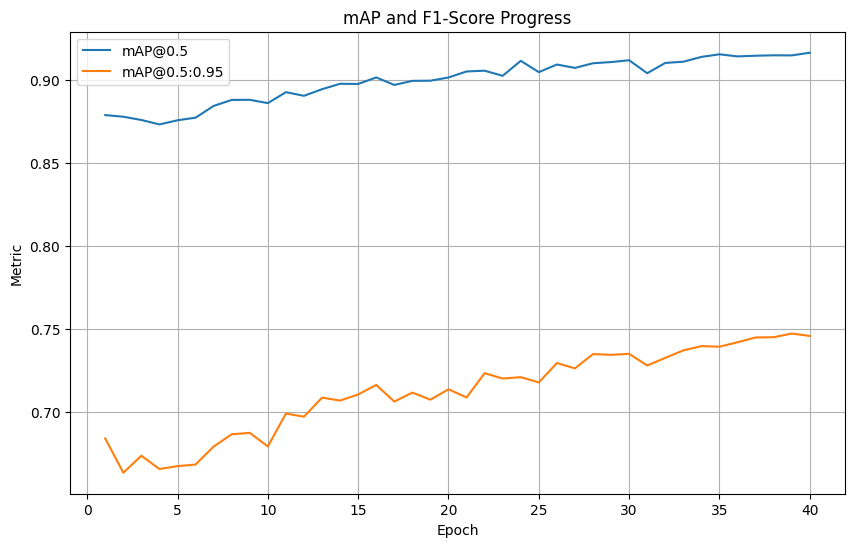

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Construct the path to the results.csv file
results_path = os.path.join( "/content/drive/MyDrive/yolo_kd_ghost_superlight/kd_ghost_superlight_v12", "results.csv")

# Read the results.csv file into a pandas DataFrame
df = pd.read_csv(results_path)

plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('mAP and F1-Score Progress')
plt.legend()
plt.grid(True)
plt.show()

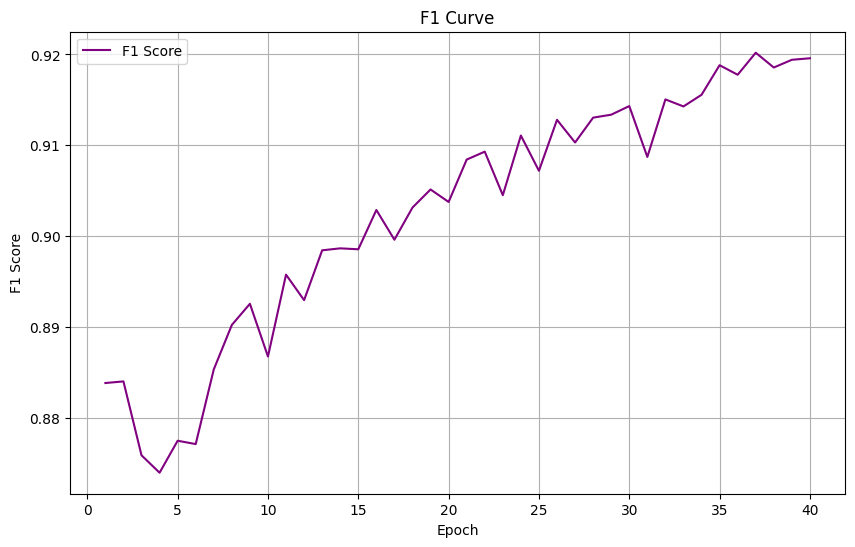

In [ ]:
plt.figure(figsize=(10,6))
f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'])
plt.plot(df['epoch'], f1, label='F1 Score', color='purple')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Curve')
plt.legend()
plt.grid(True)
plt.show()

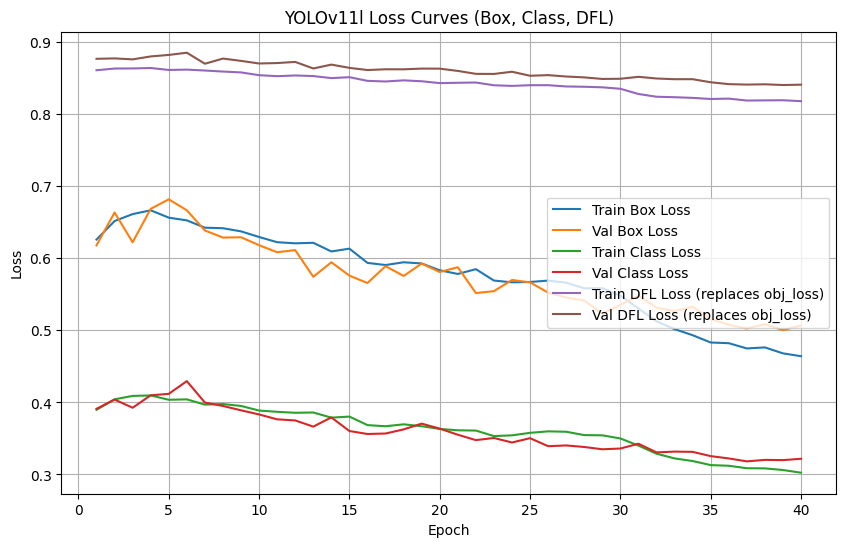

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')

plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')

plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss (replaces obj_loss)')
plt.plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss (replaces obj_loss)')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv11l Loss Curves (Box, Class, DFL)')
plt.legend()
plt.grid(True)
plt.show()


#finetune function


In [26]:
model = YOLO("/content/drive/MyDrive/yolo_kd_ghost_superlight/kd_ghost_superlight_v13/weights/best.pt")
model.info()

results = model.train(
    data=f"{"/content/drive/MyDrive/dataset/3_data_multi_view_intersection"}/data.yaml",
    epochs=50,
    imgsz=640,
    device=0,
    cache=True,
    amp=True,
    cos_lr=True,
    resume=False,
    lr0=1e-5, #learning rate
    patience=10,
    warmup_epochs=5,
    freeze = 3,
    project=PROJECT_DIR,
    name="yolo11n_pruned_ft"
)

YOLO11_tinyghost summary: 191 layers, 1,656,715 parameters, 0 gradients, 4.4 GFLOPs
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/dataset/3_data_multi_view_intersection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=3, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_kd_ghost_superlight/kd_ghost_superlight_v

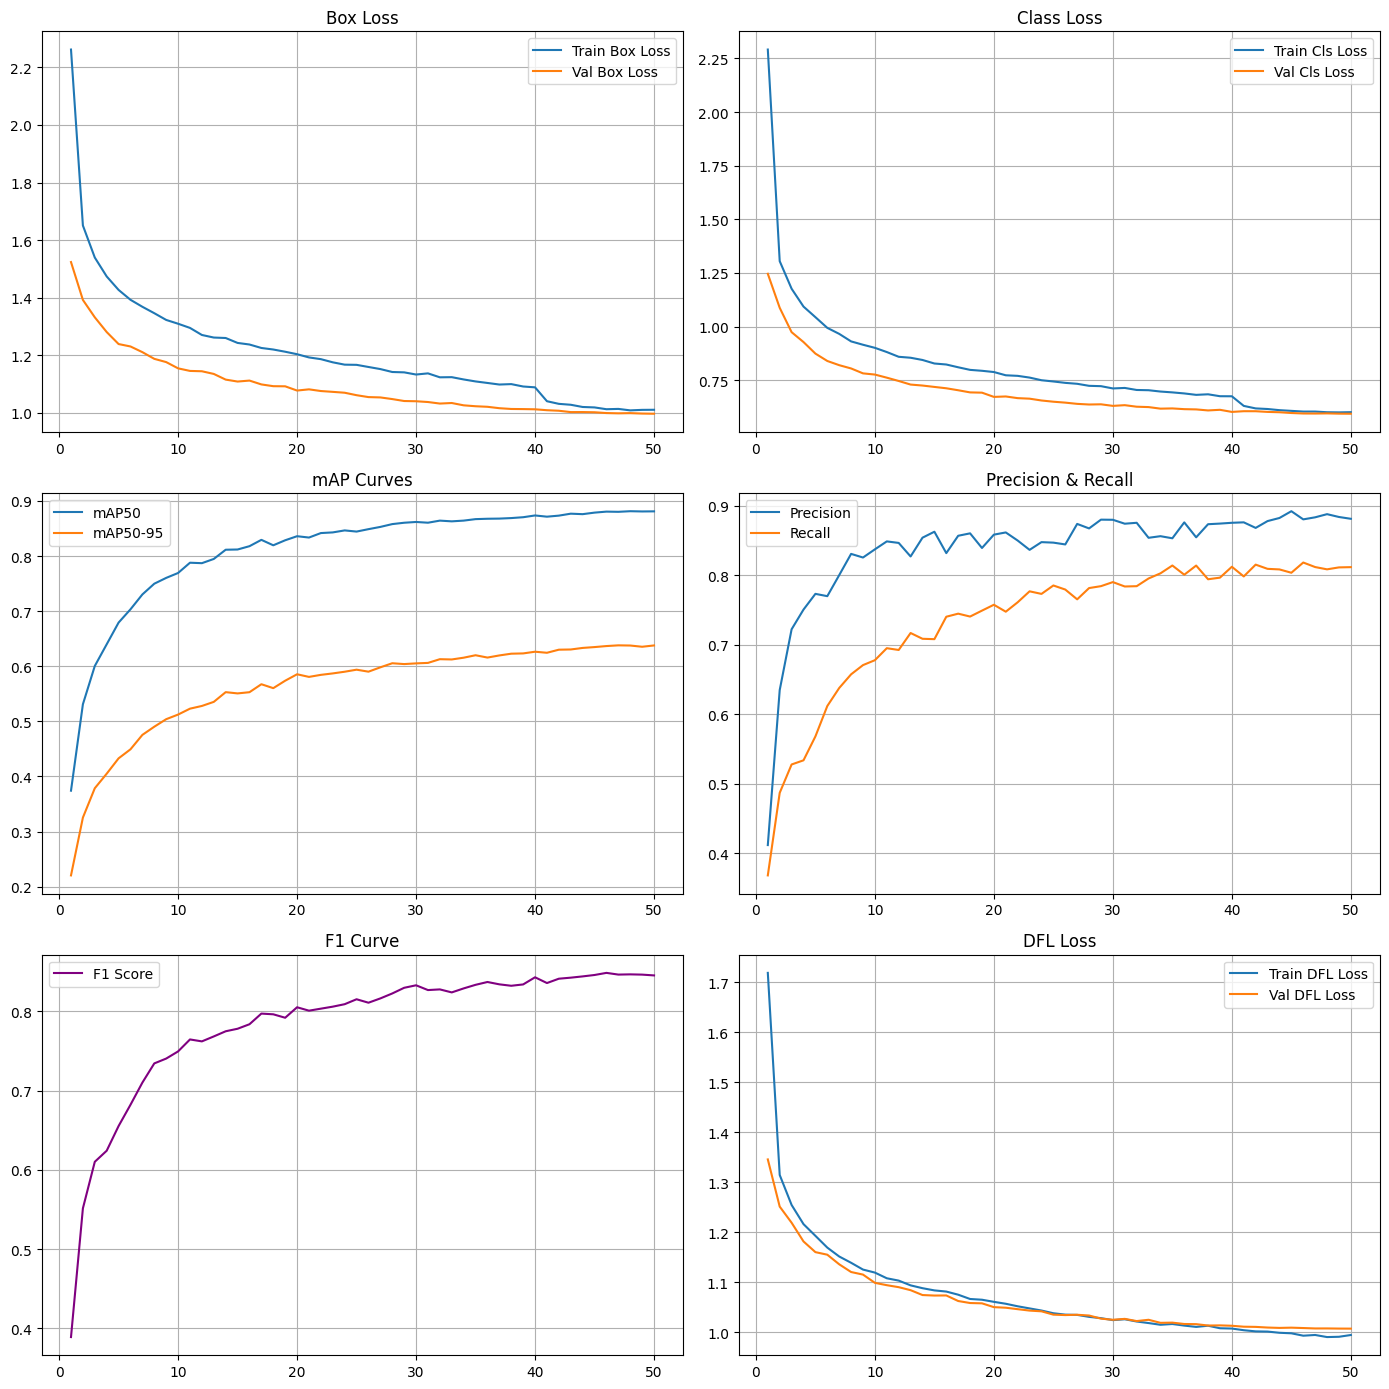

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Construct the path to the results.csv file
results_path = os.path.join("/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6", "results.csv")

# Read the results.csv file into a pandas DataFrame
df = pd.read_csv(results_path)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss')
axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss')
axes[0,1].set_title('Class Loss'); axes[0,1].legend(); axes[0,1].grid()

axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1,0].set_title('mAP Curves'); axes[1,0].legend(); axes[1,0].grid()

axes[1,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1,1].set_title('Precision & Recall'); axes[1,1].legend(); axes[1,1].grid()

f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'])
axes[2,0].plot(df['epoch'], f1, label='F1 Score', color='purple')
axes[2,0].set_title('F1 Curve'); axes[2,0].legend(); axes[2,0].grid()

axes[2,1].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
axes[2,1].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss')
axes[2,1].set_title('DFL Loss'); axes[2,1].legend(); axes[2,1].grid()


plt.tight_layout()
plt.show()

In [28]:
from ultralytics import YOLO

PT = "/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6/weights/best.pt"
DATA = "/content/drive/MyDrive/dataset/3_data_multi_view_intersection/data.yaml"

model_fp32 = YOLO(PT)
fp32_metrics = model_fp32.val(
    data=DATA,
    imgsz=640,
    device=0
)
print("FP32 done")


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11_tinyghost summary (fused): 105 layers, 1,650,321 parameters, 0 gradients, 4.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 34.2±8.4 MB/s, size: 69.5 KB)
val: Scanning /content/drive/MyDrive/dataset/3_data_multi_view_intersection/val/labels.cache... 549 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 549/549 825.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.1it/s 6.9s
                   all        549       5438      0.885      0.813      0.881      0.636
                   car        520       3842      0.898      0.893      0.948      0.708
               bicycle        189        250      0.903      0.784      0.855      0.639
                   bus         81        108      0.859      0.889      0.924      0.741
             motorbike        331       1238      0.879      0.687      

In [34]:
from ultralytics import YOLO

PT = "/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6/weights/best.pt"
DATA = "/content/drive/MyDrive/dataset/3_data_multi_view_intersection/data.yaml"

model_fp32 = YOLO(PT)
fp32_metrics = model_fp32.val(
    data=DATA,
    imgsz=416,
    device=0
)
print("FP32 done")


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11_tinyghost summary (fused): 105 layers, 1,650,321 parameters, 0 gradients, 4.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 57.6±21.8 MB/s, size: 82.0 KB)
val: Scanning /content/drive/MyDrive/dataset/3_data_multi_view_intersection/val/labels.cache... 549 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 549/549 852.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.9it/s 5.9s
                   all        549       5438      0.883      0.745       0.83      0.586
                   car        520       3842      0.872      0.837      0.909      0.656
               bicycle        189        250      0.884      0.712      0.785      0.564
                   bus         81        108      0.942       0.87       0.94      0.752
             motorbike        331       1238      0.835       0.56     

In [33]:
from ultralytics import YOLO

CALIB_YAML = "/content/drive/MyDrive/dataset/cali/data.yaml"

tflite_int8 = model_fp32.export(
    format="tflite",
    int8=True,
    data=CALIB_YAML,
    imgsz=416          # test INT8
)

print("INT8 exported to:", tflite_int8)


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 9, 3549) (3.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/drive/MyDrive/dataset/cali/data.yaml'
Fast image access ✅ (ping: 0.3±0.1 ms, read: 0.2±0.1 MB/s, size: 70.6 KB)
Scanning /content/drive/MyDrive/dataset/cali/labels... 0 images, 467 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 467/467 28.7it/s 16.3s
WARNING ⚠️ No labels found in /content/drive/MyDrive/dataset/cali/labels.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
New cache created: /content/drive/MyDrive/dataset/cali/labels.cache
WARNING ⚠️ Labels are missing or empty in /content/drive/MyDrive/dataset/cali/labels.cache, training may not work correc

In [35]:
from ultralytics import YOLO

# =========================
# PATHS
# =========================
FP32_MODEL = "/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6/weights/best.pt"
INT8_MODEL = "/content/drive/MyDrive/yolo_ghostblock/yolo11n_pruned_ft6/weights/best_saved_model/best_int8.tflite"
DATA_YAML = "/content/drive/MyDrive/dataset/3_data_multi_view_intersection/data.yaml"

IMG_SIZE = 416  # phải giống lúc export INT8

# =========================
# FP32 EVALUATION
# =========================
print("===== Evaluating FP32 model =====")
model_fp32 = YOLO(FP32_MODEL)
fp32_metrics = model_fp32.val(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    device=0
)

# =========================
# INT8 EVALUATION
# =========================
print("\n===== Evaluating INT8 model =====")
model_int8 = YOLO(INT8_MODEL)
int8_metrics = model_int8.val(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    device=0
)

# =========================
# SUMMARY
# =========================
print("\n===== SUMMARY (FP32 vs INT8) =====")

print(f"FP32  mAP50     : {fp32_metrics.box.map50:.4f}")
print(f"INT8  mAP50     : {int8_metrics.box.map50:.4f}")
print(f"Δ mAP50         : {int8_metrics.box.map50 - fp32_metrics.box.map50:+.4f}")

print(f"\nFP32  mAP50-95  : {fp32_metrics.box.map:.4f}")
print(f"INT8  mAP50-95  : {int8_metrics.box.map:.4f}")
print(f"Δ mAP50-95      : {int8_metrics.box.map - fp32_metrics.box.map:+.4f}")


===== Evaluating FP32 model =====
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11_tinyghost summary (fused): 105 layers, 1,650,321 parameters, 0 gradients, 4.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 38.1±19.1 MB/s, size: 85.6 KB)
val: Scanning /content/drive/MyDrive/dataset/3_data_multi_view_intersection/val/labels.cache... 549 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 549/549 805.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 7.9it/s 4.4s
                   all        549       5438      0.883      0.745       0.83      0.586
                   car        520       3842      0.872      0.837      0.909      0.656
               bicycle        189        250      0.884      0.712      0.785      0.564
                   bus         81        108      0.942       0.87       0.94      0.752
             motorbike        331    